# Results Dashboard

Benchmark results tables. Full analysis (charts, ablations) in `00a_results_analysis.ipynb`.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA,
    MINIMOL_GIT, MOLE, MOLGPS, FAMILY_HATCHES,
    infer_model_name, infer_model_family, build_method_label,
    load_results, load_tdc_top10, count_best_among_methods, build_method_colors,
)

# === Config: select which model(s) to show ===
MODELS_TO_SHOW = [
    'gpspp_800M',
    'pairmixer_12M',
    'pairmixer_20M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {sorted(df['model_name'].unique())}")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# Method colors: consistent color per pre-training dataset
METHOD_COLORS = build_method_colors(admet_df)

# TDC top-10 leaderboard stats for z-score normalization
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()

/home/shpark/prj-molrepr/graphium/notebooks/notebook_utils.py:385: DtypeWarning: Columns (15,17,18,19,21,22,24,311) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Loaded 1238 rows, 538 ADMET rows
Models: ['gpspp_800M', 'pairmixer_12M', 'pairmixer_20M']
Methods: ['Scratch', 'dti', 'dti_pactivity', 'largemix', 'largemix_dti', 'rxrx3', 'rxrx3_dti', 'toymix', 'toymix_bbbc047', 'toymix_dti', 'toymix_dti_esmc_v2', 'toymix_dti_filtered', 'toymix_dti_pactivity', 'toymix_dti_v2', 'toymix_lpm24', 'toymix_rxrx3', 'toymix_rxrx3_dti']


# Task 1 - ADMET

## TDC ADMET

/tmp/ipykernel_1745800/215806392.py:167: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


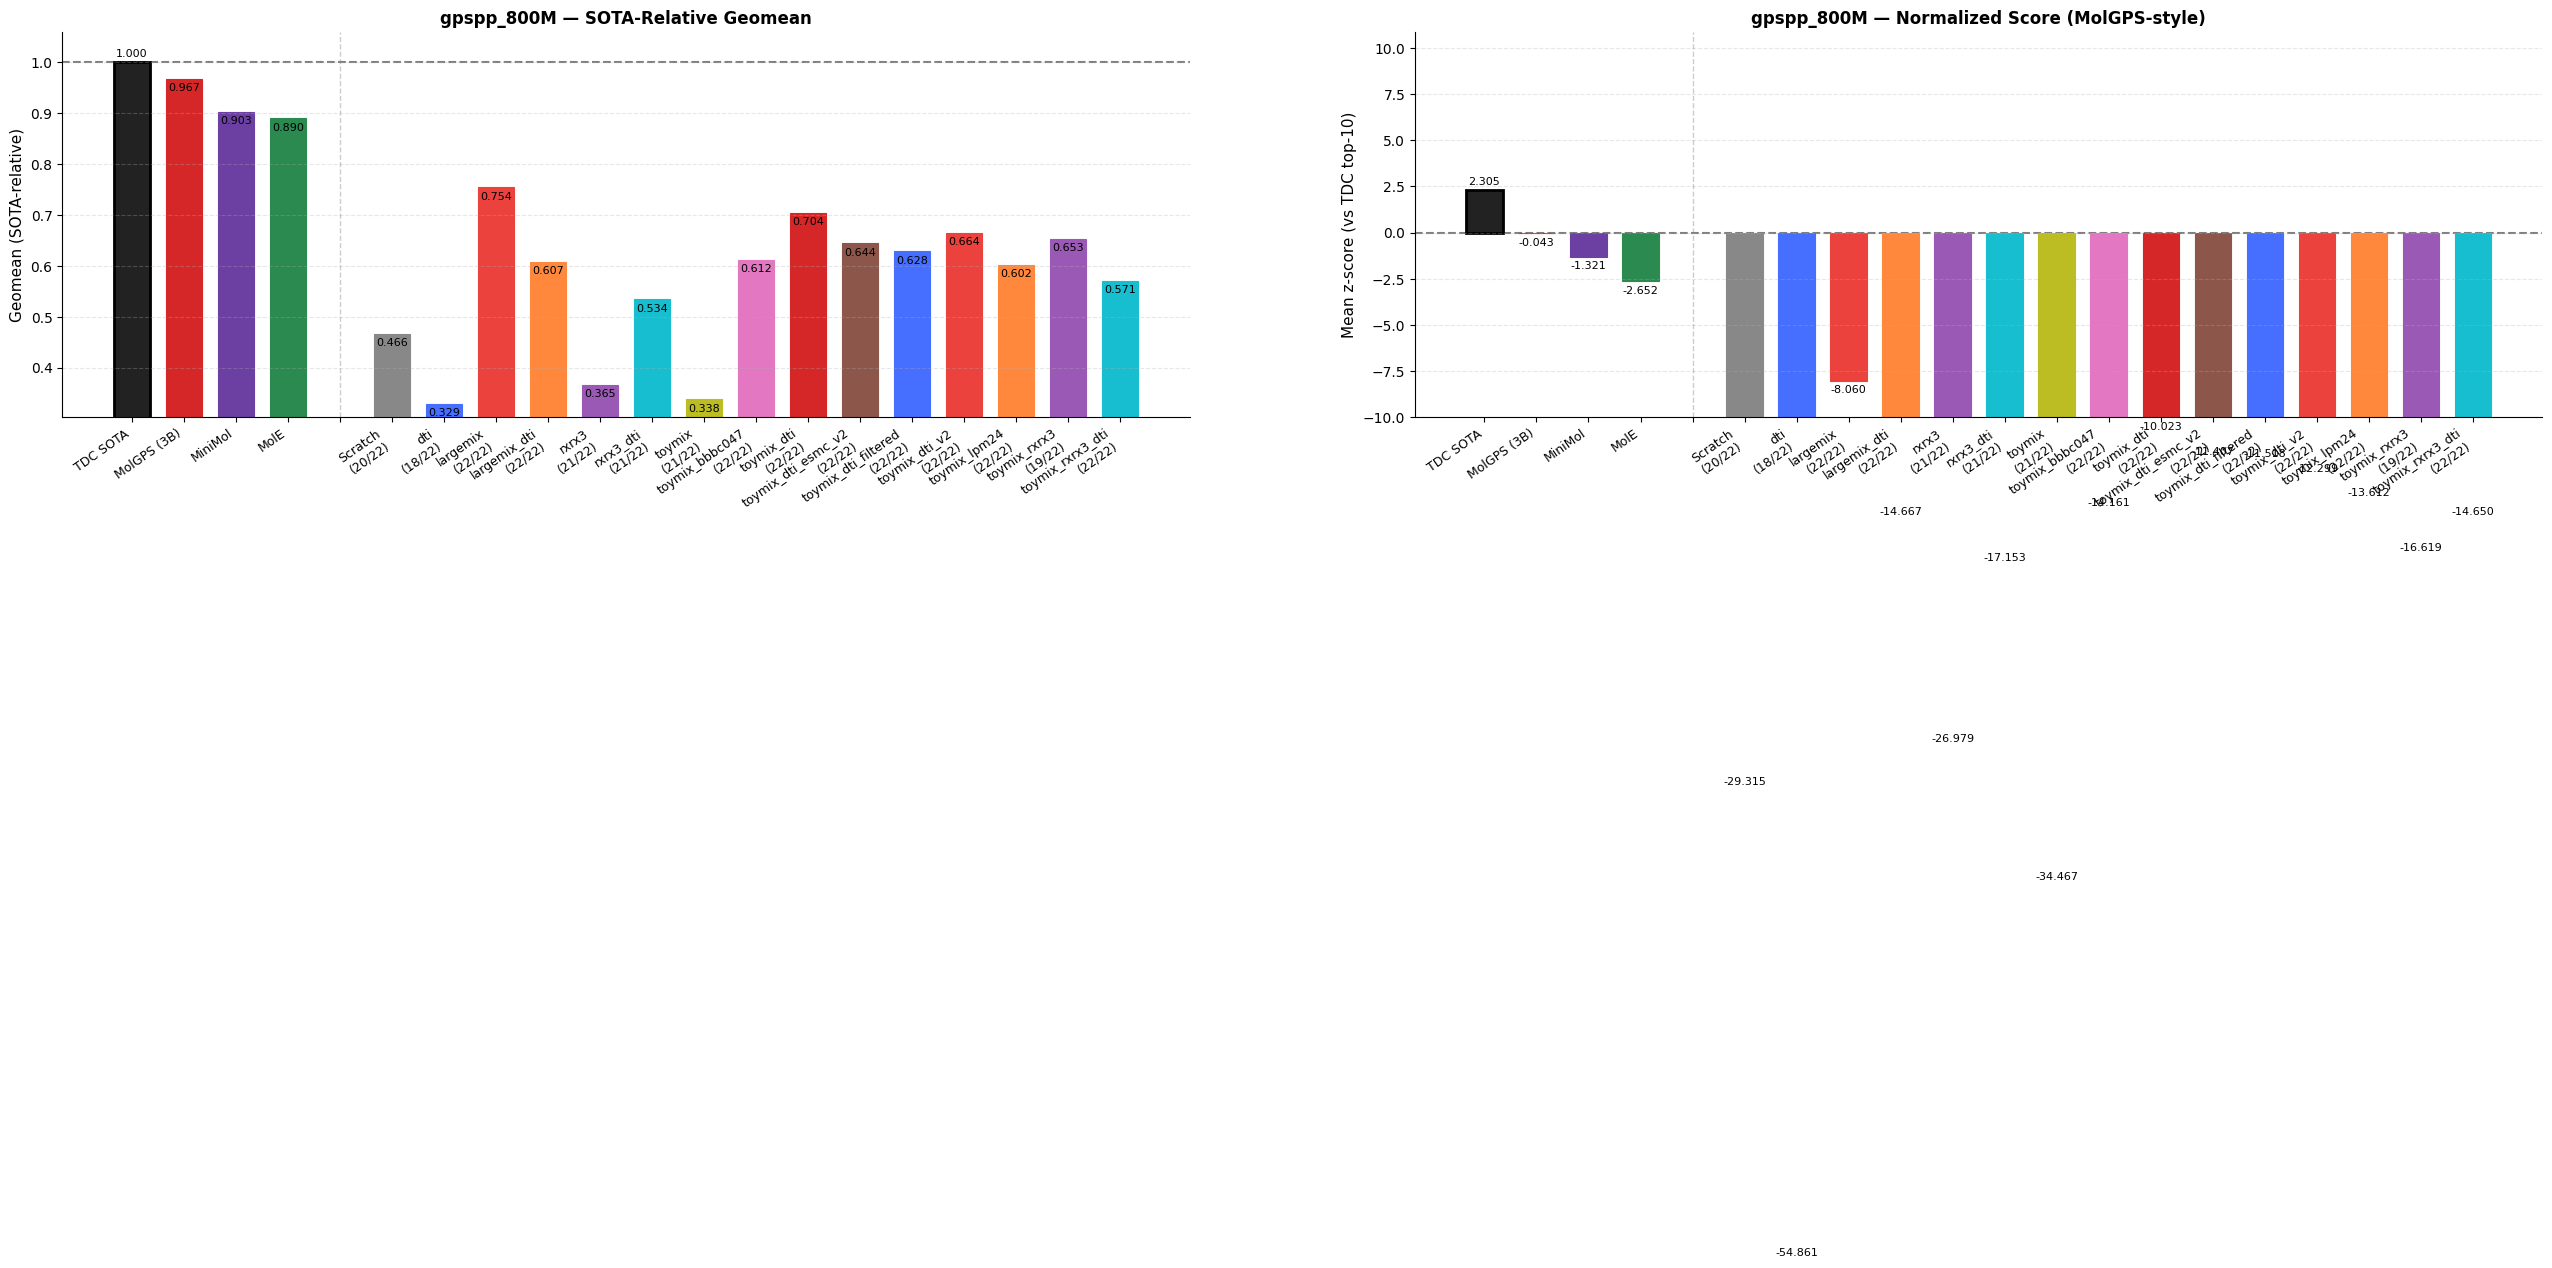


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.8901   -2.6516     22

  Scratch                      0.4663  -29.3152     20
  dti                          0.3292  -54.8605     18
  largemix                     0.7544   -8.0596     22
  largemix_dti                 0.6072  -14.6670     22
  rxrx3                        0.3652  -26.9785     21
  rxrx3_dti                    0.5342  -17.1525     21
  toymix                       0.3375  -34.4673     21
  toymix_bbbc047               0.6119  -14.1606     22
  toymix_dti                   0.7037  -10.0233     22
  toymix_dti_esmc_v2           0.6442  -11.4071     22
  toymix_dti_filtered          0.6284  -11.5179     22
  toymix_dti_v2                0.6644  -12.2986     22
  toymix

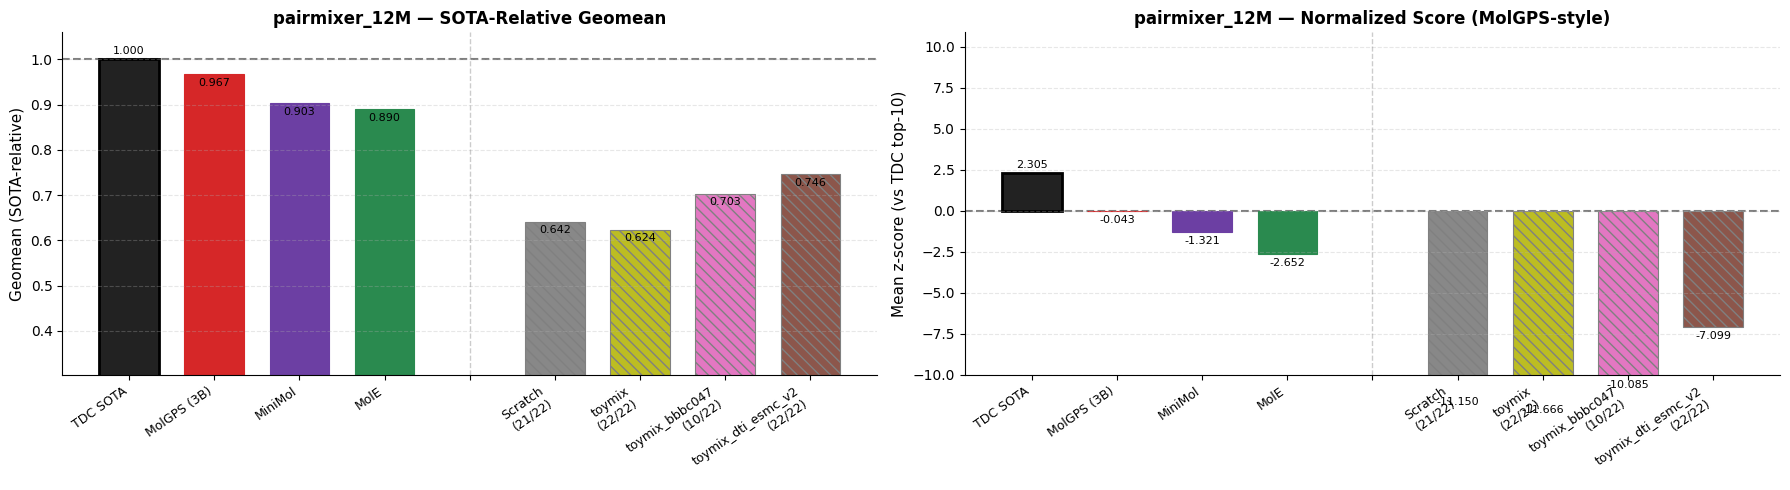


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.8901   -2.6516     22

  Scratch                      0.6415  -11.1501     21
  toymix                       0.6239  -11.6661     22
  toymix_bbbc047               0.7026  -10.0853     10
  toymix_dti_esmc_v2           0.7461   -7.0993     22



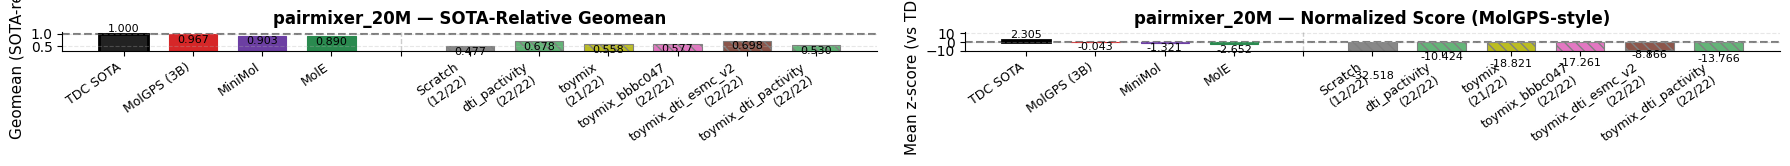


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.8901   -2.6516     22

  Scratch                      0.4767  -32.5178     12
  dti_pactivity                0.6780  -10.4240     22
  toymix                       0.5580  -18.8214     21
  toymix_bbbc047               0.5774  -17.2606     22
  toymix_dti_esmc_v2           0.6977   -8.8660     22
  toymix_dti_pactivity         0.5295  -13.7664     22



In [2]:
# Two aggregate metrics across 22 ADMET tasks:
#
# 1. SOTA-relative geomean: value/SOTA (higher-better) or SOTA/value (lower-better),
#    then geometric mean. SOTA = 1.0 by construction.
#
# 2. MolGPS-style normalized score: z-score each task relative to the TDC top-10
#    leaderboard, flip sign for lower-is-better, then arithmetic mean.
#    Positive = above leaderboard average, negative = below.

def _sota_normalize(value, task):
    """Normalize a single value relative to TDC SOTA for that task."""
    if task not in TDC_SOTA or pd.isna(value):
        return np.nan
    sota_mean = TDC_SOTA[task][0]
    direction = TASK_METRICS[task][1]
    if sota_mean == 0:
        return np.nan
    if direction == 'higher':
        return value / sota_mean
    else:
        return sota_mean / value if value != 0 else np.nan

def _zscore_normalize(value, task):
    """Z-score relative to TDC top-10 leaderboard, sign-flipped for lower-is-better."""
    if task not in TDC_TOP10_AVG or pd.isna(value):
        return np.nan
    lb_mean, lb_std = TDC_TOP10_AVG[task]
    if lb_std < 1e-12:
        return 0.0
    direction = TASK_METRICS[task][1]
    z = (value - lb_mean) / lb_std
    return z if direction == 'higher' else -z

def _geomean(values):
    """Geometric mean of positive values, ignoring NaN."""
    v = [x for x in values if np.isfinite(x) and x > 0]
    if not v:
        return np.nan
    return np.exp(np.mean(np.log(v)))

def _mean_zscore(values):
    """Arithmetic mean of z-scores, ignoring NaN."""
    v = [x for x in values if np.isfinite(x)]
    if not v:
        return np.nan
    return np.mean(v)

# --- External baselines: (display_label, data_dict, bar_color) ---
_BASELINES = [
    ('TDC SOTA',     {t: (TDC_SOTA[t][0],) for t in ADMET_TASK_ORDER if t in TDC_SOTA}, '#222222'),
    ('MolGPS (3B)',  MOLGPS,       '#d62728'),
    ('MiniMol',      MINIMOL_GIT,  '#6c3fa3'),
    ('MolE',         MOLE,         '#2a8a4f'),
]

_baseline_geomeans = {}
_baseline_zscores = {}
for _bname, _bdata, _ in _BASELINES:
    _gn = [_sota_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _zn = [_zscore_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _baseline_geomeans[_bname] = _geomean(_gn)
    _baseline_zscores[_bname] = _mean_zscore(_zn)

# --- Compute per (model, method) from our runs ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    _task_method_means = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].mean()

    _all_geomeans = list(_baseline_geomeans.values())
    _all_zscores = list(_baseline_zscores.values())
    _model_data = {}

    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]
        if len(model_df) == 0:
            continue
        methods = sorted(model_df['method'].unique(), key=lambda m: (0 if m == 'Scratch' else 1, m))
        _method_geomeans = {}
        _method_zscores = {}
        _method_ntasks = {}
        for method in methods:
            _gn, _zn = [], []
            for task in ADMET_TASK_ORDER:
                try:
                    val = _task_method_means.loc[(task, model_name, method)]
                    _gn.append(_sota_normalize(val, task))
                    _zn.append(_zscore_normalize(val, task))
                except KeyError:
                    pass
            _method_geomeans[method] = _geomean(_gn)
            _method_zscores[method] = _mean_zscore(_zn)
            _method_ntasks[method] = sum(1 for x in _gn if np.isfinite(x) and x > 0)
            if np.isfinite(_method_geomeans[method]):
                _all_geomeans.append(_method_geomeans[method])
            if np.isfinite(_method_zscores[method]):
                _all_zscores.append(_method_zscores[method])
        _model_data[model_name] = (methods, _method_geomeans, _method_zscores, _method_ntasks)

    # Shared y-axis ranges
    _gm_finite = [v for v in _all_geomeans if np.isfinite(v)]
    _gm_ymin = min(_gm_finite) * 0.92 if _gm_finite else 0
    _gm_ymax = max(_gm_finite) * 1.06 if _gm_finite else 1
    _zs_finite = [v for v in _all_zscores if np.isfinite(v)]
    _zs_pad = (max(_zs_finite) - min(_zs_finite)) * 0.15 if _zs_finite else 1
    _zs_ymin = max(min(_zs_finite) - _zs_pad, -10) if _zs_finite else -1
    _zs_ymax = max(_zs_finite) + _zs_pad if _zs_finite else 1

    baseline_names = [name for name, _, _ in _BASELINES]
    baseline_colors = {name: color for name, _, color in _BASELINES}

    for model_name in MODELS_TO_SHOW:
        if model_name not in _model_data:
            continue
        methods, _mg, _mz, _mnt = _model_data[model_name]
        family = infer_model_family(model_name)
        hatch = FAMILY_HATCHES.get(family, '')

        all_labels = baseline_names + [''] + methods
        gm_vals = [_baseline_geomeans[b] for b in baseline_names] + [np.nan] + [_mg[m] for m in methods]
        zs_vals = [_baseline_zscores[b] for b in baseline_names] + [np.nan] + [_mz[m] for m in methods]
        n = len(all_labels)
        x = np.arange(n)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(18, n * 1.6), 5))

        for ax, vals, ylabel, title_suffix, ymin, ymax, refline in [
            (ax1, gm_vals, 'Geomean (SOTA-relative)', 'SOTA-Relative Geomean', _gm_ymin, _gm_ymax, 1.0),
            (ax2, zs_vals, 'Mean z-score (vs TDC top-10)', 'Normalized Score (MolGPS-style)', _zs_ymin, _zs_ymax, 0.0),
        ]:
            for i, (label, val) in enumerate(zip(all_labels, vals)):
                if label == '' or pd.isna(val):
                    continue
                if label in baseline_colors:
                    color = baseline_colors[label]
                    h = ''
                    ec = 'black' if label == 'TDC SOTA' else color
                    lw = 2.0 if label == 'TDC SOTA' else 0.8
                else:
                    color = METHOD_COLORS.get(label, '#466eff')
                    h = hatch
                    ec = 'grey' if h else color
                    lw = 0.8
                ax.bar(i, val, color=color, hatch=h, edgecolor=ec, linewidth=lw, width=0.7)
                offset = (ymax - ymin) * 0.01
                va = 'bottom' if val >= refline else 'top'
                ax.text(i, val + (offset if va == 'bottom' else -offset),
                        f'{val:.3f}', ha='center', va=va, fontsize=8)

            ax.axhline(y=refline, color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=0)
            sep_x = len(baseline_names)
            ax.axvline(x=sep_x - 0.5 + 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.4)
            ax.set_xticks(x)
            _xlabels = []
            for label in all_labels:
                if label == '' or label in baseline_colors:
                    _xlabels.append(label)
                else:
                    _nt = _mnt.get(label, 0)
                    _xlabels.append(f'{label}\n({_nt}/{len(ADMET_TASK_ORDER)})')
            ax.set_xticklabels(_xlabels, rotation=35, ha='right', fontsize=9)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(f'{model_name} — {title_suffix}', fontsize=12, fontweight='bold')
            ax.set_ylim(ymin, ymax)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print table
        print(f"\n{'':2s}{'Method':25s}  {'Geomean':>8s}  {'Z-score':>8s}  {'Tasks':>5s}")
        print("  " + "-" * 52)
        for b in baseline_names:
            print(f"  {b:25s}  {_baseline_geomeans[b]:>8.4f}  {_baseline_zscores[b]:>8.4f}  {22:>5d}")
        print()
        for m in methods:
            print(f"  {m:25s}  {_mg[m]:>8.4f}  {_mz[m]:>8.4f}  {_mnt[m]:>5d}")
        print()
else:
    print("No ADMET results to plot.")

In [3]:
print(f"ADMET results: {len(admet_df)} rows")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# --- Compute global best (across all architectures) per task ---
global_best_per_task = {}  # task -> (model_name, method)
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for task in ADMET_TASK_ORDER:
        task_rows = admet_df[admet_df['task'] == task].dropna(subset=['primary_metric'])
        if len(task_rows) == 0:
            continue
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        if direction == 'lower':
            best_row = task_rows.loc[task_rows['primary_metric'].idxmin()]
        else:
            best_row = task_rows.loc[task_rows['primary_metric'].idxmax()]
        global_best_per_task[task] = (best_row['model_name'], best_row['method'])

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]

        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            # No data at all — show empty table with all tasks
            pivot = pd.DataFrame(index=ADMET_TASK_ORDER, columns=['(no results)'])
            pivot['(no results)'] = np.nan
        else:
            pivot = model_df.pivot_table(
                index='task', columns='method', values='primary_metric', aggfunc='mean'
            )
            method_order = ['Scratch'] + sorted([c for c in pivot.columns if c != 'Scratch'])
            method_order += [c for c in pivot.columns if c not in method_order]
            pivot = pivot[[c for c in method_order if c in pivot.columns]]

        # Reindex to always show all 22 ADMET tasks (NaN for missing)
        pivot = pivot.reindex(ADMET_TASK_ORDER)

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: bold = best within arch, blue+underline = best across all archs
        def make_highlight(arch_best, global_best, cur_model, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                cols = list(dp.columns)
                metric_info = TASK_METRICS.get(task, (None, None))
                direction = metric_info[1]
                sota_info = TDC_SOTA.get(task)

                for j, col in enumerate(cols):
                    if col == 'TDC SOTA':
                        continue
                    try:
                        val = float(row.iloc[j])
                    except (ValueError, TypeError):
                        continue
                    if pd.isna(val):
                        continue

                    # Check if value exceeds SOTA (within std)
                    exceeds_sota = False
                    if sota_info is not None and direction is not None:
                        sota_mean, sota_std, _ = sota_info
                        if direction == 'higher' and val >= sota_mean - sota_std:
                            exceeds_sota = True
                        elif direction == 'lower' and val <= sota_mean + sota_std:
                            exceeds_sota = True

                    if exceeds_sota:
                        styles[j] = 'font-weight: bold; color: #cc0000'

                # Architecture best: bold (overrides red if not exceeding SOTA)
                if task in arch_best:
                    j = cols.index(arch_best[task])
                    if 'color: #cc0000' not in styles[j]:
                        styles[j] = 'font-weight: bold'

                # Global best: blue + underline (overrides arch-best, but not red)
                if task in global_best:
                    g_model, g_method = global_best[task]
                    if g_model == cur_model and g_method in cols:
                        k = cols.index(g_method)
                        if 'color: #cc0000' not in styles[k]:
                            styles[k] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'

                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, global_best_per_task,
                                  model_name, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )

        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
        print("Bold = best within architecture | Blue + underline = best across all architectures")
        display(styled)

        # Count tasks where each method is the best
        best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
        if best_counts:
            print(f"\nTasks where each method is best ({model_name}):")
            for method, (wins, total) in best_counts.items():
                print(f"  {method}: {wins}/{total}")

    # --- Cross-architecture summary ---
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

ADMET results: 538 rows
Methods: ['Scratch', 'dti', 'dti_pactivity', 'largemix', 'largemix_dti', 'rxrx3', 'rxrx3_dti', 'toymix', 'toymix_bbbc047', 'toymix_dti', 'toymix_dti_esmc_v2', 'toymix_dti_filtered', 'toymix_dti_pactivity', 'toymix_dti_v2', 'toymix_lpm24', 'toymix_rxrx3', 'toymix_rxrx3_dti']

  gpspp_800M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
caco2_wang (mae ↓),0.256 ± 0.006,0.8231,5.3263,0.4899,0.5056,1.2462,0.7230,5.2247,0.4873,0.4466,0.4936,0.5672,0.5379,0.5891,0.5438,0.5284
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.9014,0.6840,0.4988,0.7267,0.8333,0.9150,0.8712,0.9457,0.9506,0.8317,0.7700,0.6066,0.7313
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8214,0.5000,0.8890,0.8134,0.4373,0.8194,0.8155,0.7902,0.8919,0.8632,0.7996,0.7353,0.7792,0.8305,0.7345
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.5000,0.5000,0.5271,0.5316,0.5037,0.5786,0.6275,0.4613,0.5632,0.5614,0.6345,0.5735,0.6209,0.5449,0.5883
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.9721,2.3666,0.7559,0.8889,0.9677,0.9647,0.9724,0.8961,0.8436,0.9017,0.9145,0.9381,0.9462,0.9782,0.9174
solubility_aqsoldb (mae ↓),0.679 ± 0.000,1.0424,3.4085,1.0715,1.5022,1.8897,1.4641,1.4957,1.4241,1.2442,1.3547,1.3231,1.4160,1.4697,1.2084,1.2582
bbb_martins (auroc ↑),0.941 ± 0.000,0.7324,0.5000,0.8485,0.7972,0.5569,0.7043,0.3988,0.7403,0.8080,0.7504,0.8086,0.7839,0.7218,0.7836,0.7282
ppbr_az (mae ↓),6.464 ± 0.000,81.4208,88.6763,8.5499,9.4128,17.4642,15.7294,13.3702,9.6523,8.8819,8.9358,9.5635,9.8405,9.5194,9.6962,9.6880
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.4888,0.4398,0.0541,0.2888,0.2426,0.5075,0.5988,0.5926,0.5317,0.4536,0.4953,0.3875,0.4868
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.6463,0.4494,0.1488,0.4021,0.1469,0.4283,0.5229,0.4114,0.3949,0.4593,0.4113,0.4564,0.4094



Tasks where each method is best (gpspp_800M):
  Scratch: 2/22
  dti: 0/22
  largemix: 10/22
  largemix_dti: 0/22
  rxrx3: 0/22
  rxrx3_dti: 0/22
  toymix: 1/22
  toymix_bbbc047: 0/22
  toymix_dti: 4/22
  toymix_dti_esmc_v2: 0/22
  toymix_dti_filtered: 2/22
  toymix_dti_v2: 2/22
  toymix_lpm24: 1/22
  toymix_rxrx3: 0/22
  toymix_rxrx3_dti: 0/22

  pairmixer_12M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,toymix,toymix_bbbc047,toymix_dti_esmc_v2
caco2_wang (mae ↓),0.256 ± 0.006,0.5938,0.8164,0.5547,0.6133
hia_hou (auroc ↑),0.993 ± 0.005,0.8424,0.9374,0.9652,0.9593
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8753,0.9020,0.9029,0.8870
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6127,0.5883,0.7281,0.6147
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.5586,0.9375,0.8828,0.8242
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.7969,1.1797,1.0938,1.0156
bbb_martins (auroc ↑),0.941 ± 0.000,0.8796,0.7690,0.8040,0.8668
ppbr_az (mae ↓),6.464 ± 0.000,26.1250,11.6875,8.4375,8.5625
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5508,0.4766,0.5664,0.5703
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.5238,0.4979,0.4946,0.6188



Tasks where each method is best (pairmixer_12M):
  Scratch: 6/22
  toymix: 1/22
  toymix_bbbc047: 5/22
  toymix_dti_esmc_v2: 10/22

  pairmixer_20M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti_pactivity,toymix,toymix_bbbc047,toymix_dti_esmc_v2,toymix_dti_pactivity
caco2_wang (mae ↓),0.256 ± 0.006,1.0859,0.4355,0.9844,0.6094,0.4551,0.6484
hia_hou (auroc ↑),0.993 ± 0.005,0.7864,0.8663,0.7852,0.8374,0.9352,0.9471
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8507,0.8286,0.8116,0.7696,0.8819,0.8551
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6811,0.6162,0.6746,0.4995,0.7183,0.6274
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.8086,0.8672,0.9570,0.9844,0.9141,0.9531
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.8867,1.2422,1.5938,1.8906,1.3203,1.4297
bbb_martins (auroc ↑),0.941 ± 0.000,0.7347,0.8249,0.4757,0.6435,0.7682,0.7001
ppbr_az (mae ↓),6.464 ± 0.000,74.5000,11.1250,10.5625,9.8750,9.0000,10.7500
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5234,0.5273,0.2656,0.4336,0.5977,0.5664
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1687,0.4576,0.3445,0.2788,0.3914,0.3144



Tasks where each method is best (pairmixer_20M):
  Scratch: 2/22
  dti_pactivity: 6/22
  toymix: 0/22
  toymix_bbbc047: 1/22
  toymix_dti_esmc_v2: 12/22
  toymix_dti_pactivity: 1/22

  Cross-architecture summary: tasks where each (model, method) is best
  gpspp_800M / Scratch: 0/22
  gpspp_800M / dti: 0/22
  gpspp_800M / largemix: 4/22
  gpspp_800M / largemix_dti: 0/22
  gpspp_800M / rxrx3: 0/22
  gpspp_800M / rxrx3_dti: 0/22
  gpspp_800M / toymix: 0/22
  gpspp_800M / toymix_bbbc047: 0/22
  gpspp_800M / toymix_dti: 2/22
  gpspp_800M / toymix_dti_esmc_v2: 0/22
  gpspp_800M / toymix_dti_filtered: 0/22
  gpspp_800M / toymix_dti_v2: 0/22
  gpspp_800M / toymix_lpm24: 0/22
  gpspp_800M / toymix_rxrx3: 0/22
  gpspp_800M / toymix_rxrx3_dti: 0/22
  pairmixer_12M / Scratch: 6/22
  pairmixer_12M / toymix: 0/22
  pairmixer_12M / toymix_bbbc047: 4/22
  pairmixer_12M / toymix_dti_esmc_v2: 2/22
  pairmixer_20M / Scratch: 0/22
  pairmixer_20M / dti_pactivity: 2/22
  pairmixer_20M / toymix: 0/22
  pai

## Polaris ADME-Fang

Six single-task regression benchmarks from the Polaris `biogen/adme-fang-v1` suite.
Primary metric: **Pearson r** (higher is better).

In [4]:
_FANG_TASKS = [
    'adme_fang_hclint', 'adme_fang_rclint', 'adme_fang_perm',
    'adme_fang_hppb', 'adme_fang_rppb', 'adme_fang_solu',
]
_FANG_LABELS = {
    'adme_fang_hclint': 'Human CLint',
    'adme_fang_rclint': 'Rat CLint',
    'adme_fang_perm':   'Permeability',
    'adme_fang_hppb':   'Human PPB',
    'adme_fang_rppb':   'Rat PPB',
    'adme_fang_solu':   'Solubility',
}
_FANG_METRIC_COLS = [
    ('pearsonr',  'pearsonr \u2191',  'higher', True),   # main metric
    ('spearmanr', 'spearmanr \u2191', 'higher', False),
    ('r2_score',  'r2 \u2191',        'higher', False),
    ('mae',       'mae \u2193',       'lower',  False),
    ('mse',       'mse \u2193',       'lower',  False),
]

# Polaris leaderboard SOTA (pearsonr, rank #1). Source: polarishub.io, 2026-04.
_FANG_SOTA = {
    'adme_fang_perm':   ('(unnamed)',  0.725),
    'adme_fang_hppb':   ('MolGPS-ens', 0.886),
    'adme_fang_rppb':   ('MolGPS-ens', 0.892),
    'adme_fang_solu':   ('MolGPS-ens', 0.781),
}

# --- graphium-train rows (from experiment_results.csv) ---
_fang_df = df[df['task'].isin(_FANG_TASKS)].copy()
_fang_df['method'] = _fang_df.apply(build_method_label, axis=1)
_fang_df['model_name'] = _fang_df.apply(infer_model_name, axis=1)
_fang_df = _fang_df[_fang_df['model_name'] != 'pairmixer_20M']

# Dedup to latest run per (task, model_name, method)
_fang_df['timestamp'] = pd.to_datetime(_fang_df['timestamp'], errors='coerce')
_fang_df = _fang_df.sort_values('timestamp').drop_duplicates(
    subset=['task', 'model_name', 'method'], keep='last'
).reset_index(drop=True)

# --- Frozen-feature baselines (sklearn head on pretrained embeddings) ---
# Each CSV is long-format: one row per (benchmark, task, seed, head). We aggregate
# over seeds and render mean +/- std for multi-seed runs, bare mean for single-seed.
_FROZEN_SOURCES = [
    # (csv_name, model_label_fn, method_label_fn)
    ('pairmixer_admet_results.csv',
     lambda r: (r.get('ckpt_tag') or r.get('model') or 'pairmixer'),
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
    ('minimol_results.csv',
     lambda r: 'MiniMol',
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
    ('mole_results.csv',
     lambda r: 'MolE',
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
]
_frozen_metric_names = [m[0] for m in _FANG_METRIC_COLS]
_frozen_rows_by_task = {t: [] for t in _FANG_TASKS}
for _csv_name, _model_fn, _method_fn in _FROZEN_SOURCES:
    _p = Path(f'../results/{_csv_name}')
    if not _p.exists():
        continue
    _ext = pd.read_csv(_p)
    if 'benchmark' in _ext.columns:
        _ext = _ext[_ext['benchmark'] == 'polaris']
    _ext = _ext[_ext['task'].isin(_FANG_TASKS)].copy()
    if len(_ext) == 0:
        continue
    _ext['_model'] = _ext.apply(_model_fn, axis=1)
    _ext['_method'] = _ext.apply(_method_fn, axis=1)
    _agg_cols = [c for c in _frozen_metric_names if c in _ext.columns]
    if not _agg_cols:
        continue
    _grp = _ext.groupby(['task', '_model', '_method'])[_agg_cols].agg(['mean', 'std', 'count'])
    for (_task_key, _model_label, _method_label), _r in _grp.iterrows():
        _frozen_rows_by_task[_task_key].append({
            'model_label': _model_label,
            'method_label': _method_label,
            'stats': {m: (_r[(m, 'mean')], _r[(m, 'std')], int(_r[(m, 'count')])) for m in _agg_cols},
        })

if len(_fang_df) > 0 or any(_frozen_rows_by_task.values()):
    _rows = []
    for _task in _FANG_TASKS:
        _label = _FANG_LABELS[_task]
        _tdf = _fang_df[_fang_df['task'] == _task]
        _frozen_here = _frozen_rows_by_task.get(_task, [])

        # SOTA row
        if _task in _FANG_SOTA:
            _sname, _sval = _FANG_SOTA[_task]
            _sr = {'Task': _label, 'Model': _sname + ' (SOTA)'}
            for _msuf, _mdisp, _, _is_main in _FANG_METRIC_COLS:
                _sr[_mdisp] = f'{_sval:.3f}' if _msuf == 'pearsonr' else ''
            _rows.append(_sr)

        if len(_tdf) == 0 and not _frozen_here:
            _row = {'Task': _label, 'Model': '(no results)'}
            for _, _mdisp, _, _ in _FANG_METRIC_COLS:
                _row[_mdisp] = '-'
            _rows.append(_row)
            continue

        # graphium-train rows
        for _, _r in _tdf.iterrows():
            _mname = _r['model_name']
            _method = _r['method']
            _row = {'Task': _label, 'Model': f'{_mname} / {_method}'}
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _col = [c for c in _tdf.columns
                        if _task in c and f'/{_msuf}/' in c and 'test' in c]
                _val = pd.to_numeric(_r[_col[0]], errors='coerce') if _col else np.nan
                _row[_mdisp] = f'{_val:.4f}' if pd.notna(_val) else '-'
            _rows.append(_row)

        # frozen-feature rows (mean +/- std over seeds)
        for _fr in _frozen_here:
            _row = {
                'Task': _label,
                'Model': f"{_fr['model_label']} / {_fr['method_label']}",
            }
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _st = _fr['stats'].get(_msuf)
                if _st is None or pd.isna(_st[0]):
                    _row[_mdisp] = '-'
                else:
                    _mean, _std, _n = _st
                    if _n > 1 and pd.notna(_std):
                        _row[_mdisp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                    else:
                        _row[_mdisp] = f'{_mean:.4f}'
            _rows.append(_row)

    _result = pd.DataFrame(_rows)
    _metric_cols = [d for _, d, _, _ in _FANG_METRIC_COLS]
    _main_col = [d for _, d, _, m in _FANG_METRIC_COLS if m][0]

    # Multi-row index: group by Task
    _result = _result.set_index(['Task', 'Model'])

    def _style_fang(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        # SOTA rows: main metric bold + underlined, rest grey
        for _idx in _s.index:
            if '(SOTA)' in str(_idx[1]):
                _styles.loc[_idx] = 'background-color: #f0f0f0; color: #555; font-size: 0.9em'
                if _main_col in _styles.columns:
                    _styles.loc[_idx, _main_col] = 'background-color: #f0f0f0; font-weight: bold; text-decoration: underline'
        return _styles

    # Compute row-level border positions for task boundaries (full-row via set_table_styles)
    _row_styles = [
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_task = None
    for _i, _idx in enumerate(_result.index):
        _cur_task = _idx[0]
        if _prev_task is not None and _cur_task != _prev_task:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_i + 1})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_task = _cur_task

    _styled = (
        _result.style
        .apply(_style_fang, axis=None)
        .set_caption('ADME Fang (Polaris) \u2014 All Metrics (main: pearsonr, underlined)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # LaTeX output
    print('\n% LaTeX (copy-paste for paper):')
    print(_result.to_latex(multirow=True, escape=False))
else:
    print('No ADME Fang results yet.')


% LaTeX (copy-paste for paper):
\begin{tabular}{lllllll}
\toprule
 &  & pearsonr ↑ & spearmanr ↑ & r2 ↑ & mae ↓ & mse ↓ \\
Task & Model &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{Human CLint} & pairmixer_12M / Scratch & 0.5820 & 0.6016 & 0.2617 & 0.3984 & 0.2871 \\
 & pairmixer_12M / toymix & 0.5078 & 0.5312 & -0.0312 & 0.4766 & 0.4004 \\
 & pairmixer_12M / toymix_dti_esmc_v2 & 0.4707 & 0.4805 & -0.0156 & 0.4727 & 0.3965 \\
 & pairmixer_12M_toymix_dti_esmc_v2 / frozen-mlp & 0.4832 ± 0.0608 & 0.5075 ± 0.0527 & 0.0923 ± 0.1219 & 0.4672 ± 0.0251 & 0.3527 ± 0.0474 \\
 & MiniMol / frozen-mlp & 0.7226 & 0.7149 & 0.5205 & 0.3467 & 0.1863 \\
\cline{1-7}
\multirow[t]{4}{*}{Rat CLint} & pairmixer_12M / Scratch & 0.5664 & 0.5977 & 0.2773 & 0.4824 & 0.3945 \\
 & pairmixer_12M / toymix & 0.4785 & 0.4688 & -0.0156 & 0.5977 & 0.5508 \\
 & pairmixer_12M / toymix_dti_esmc_v2 & 0.5273 & 0.5234 & 0.1328 & 0.5469 & 0.4727 \\
 & pairmixer_12M_toymix_dti_esmc_v2 / frozen-mlp & 0.5603 ± 0.0492 & 0.5694 ±

# Task 2 - Protein Related

## TDC DTI

TDC DTI benchmarks (DAVIS, KIBA) evaluated under `random` and `cold_target` splits.
Results aggregated over seeds (mean ± std).

In [5]:
_DTI_SUBSETS = ['DAVIS', 'KIBA']
_DTI_METHODS = ['random', 'cold_target']
_DTI_METRIC_COLS = [
    ('concordance_index', 'CI \u2191',      'higher', True),
    ('pearsonr',          'pearsonr \u2191', 'higher', False),
    ('spearmanr',         'spearmanr \u2191','higher', False),
    ('mae',               'MAE \u2193',      'lower',  False),
]
_DTI_ENCODER_LABELS = {
    'minimol':   'MiniMol',
    'mole':      'MolE',
    'pairmixer': 'PairMixer',
    # Legacy rows from dep_*_dti_results.csv used the older 'model' column.
    'minimol_v1':      'MiniMol',
    'mole_gin_concat': 'MolE',
}

# Primary source: the unified per-task CSV written by downstream.tasks.tdc_dti_regression.eval.
# Fallback: the per-encoder legacy CSVs (now dep_*). Concatenating both lets us keep
# historical rows visible while the new pipeline warms up.
_dti_frames = []
_new_path = Path('../results/downstream/tdc_dti_regression.csv')
if _new_path.exists():
    _new_df = pd.read_csv(_new_path)
    # Normalize to the legacy column name the rest of this cell expects.
    if 'encoder' in _new_df.columns and 'model' not in _new_df.columns:
        _new_df = _new_df.rename(columns={'encoder': 'model'})
    _dti_frames.append(_new_df)
for _legacy in ['dep_minimol_dti_results.csv', 'dep_mole_dti_results.csv',
                'dep_pairmixer_dti_results.csv']:
    _p = Path(f'../results/{_legacy}')
    if _p.exists():
        _dti_frames.append(pd.read_csv(_p))

if _dti_frames:
    _dti_all = pd.concat(_dti_frames, ignore_index=True, sort=False)
    _dti_all['model_label'] = _dti_all['model'].map(
        lambda m: _DTI_ENCODER_LABELS.get(str(m), str(m))
    )

    # Aggregate mean/std over the seed dimension (5 seeds per split by convention).
    _group_cols = ['model_label', 'subset', 'method']
    _metric_names = [m[0] for m in _DTI_METRIC_COLS]
    _metric_names = [m for m in _metric_names if m in _dti_all.columns]
    _agg = _dti_all.groupby(_group_cols)[_metric_names].agg(['mean', 'std', 'count'])

    _models_sorted = sorted({lbl for lbl in _dti_all['model_label'].unique()
                             if isinstance(lbl, str) and lbl})

    _rows = []
    for _subset in _DTI_SUBSETS:
        for _method in _DTI_METHODS:
            for _model_label in _models_sorted:
                _row = {'Dataset': _subset, 'Split': _method, 'Model': _model_label}
                try:
                    _stats = _agg.loc[(_model_label, _subset, _method)]
                except KeyError:
                    for _, _disp, _, _ in _DTI_METRIC_COLS:
                        _row[_disp] = '-'
                    _rows.append(_row)
                    continue
                for _msuf, _disp, _, _ in _DTI_METRIC_COLS:
                    if _msuf not in _metric_names:
                        _row[_disp] = '-'
                        continue
                    _mean = _stats[(_msuf, 'mean')]
                    _std = _stats[(_msuf, 'std')]
                    _n = _stats[(_msuf, 'count')]
                    if pd.notna(_mean):
                        if pd.notna(_std) and _n > 1:
                            _row[_disp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                        else:
                            _row[_disp] = f'{_mean:.4f}'
                    else:
                        _row[_disp] = '-'
                _rows.append(_row)

    _result = pd.DataFrame(_rows).set_index(['Dataset', 'Split', 'Model'])

    # Bold best model per (dataset, split) for each metric.
    def _style_dti(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _dataset in _s.index.get_level_values(0).unique():
            for _split in _s.index.get_level_values(1).unique():
                try:
                    _grp = _s.loc[(_dataset, _split)]
                except KeyError:
                    continue
                for _msuf, _disp, _direction, _is_main in _DTI_METRIC_COLS:
                    if _disp not in _s.columns:
                        continue
                    _vals = []
                    for _model_idx in _grp.index:
                        _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                        try:
                            _vals.append((_model_idx, float(_raw)))
                        except ValueError:
                            pass
                    if len(_vals) < 2:
                        continue
                    if _direction == 'lower':
                        _best_model = min(_vals, key=lambda x: x[1])[0]
                    else:
                        _best_model = max(_vals, key=lambda x: x[1])[0]
                    _styles.loc[(_dataset, _split, _best_model), _disp] += 'font-weight: bold'
        return _styles

    # Row borders between dataset / split boundaries.
    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_dataset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_dataset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_dataset is not None and _cur_dataset != _prev_dataset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_dataset = _cur_dataset
        _prev_split = _cur_split

    _styled = (
        _result.style
        .apply(_style_dti, axis=None)
        .set_caption('TDC DTI Regression (DAVIS, KIBA) \u2014 mean \u00b1 std over seeds  (main: CI, bolded)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    print('\n% LaTeX (copy-paste for paper):')
    print(_result.to_latex(multirow=True, escape=False))
else:
    print('No DTI regression results found. Run: bash scripts/tdc_dti_regression/run_all.sh')

/tmp/ipykernel_1745800/3713572401.py:86: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _s.loc[(_dataset, _split)]



% LaTeX (copy-paste for paper):
\begin{tabular}{lllllll}
\toprule
 &  &  & CI ↑ & pearsonr ↑ & spearmanr ↑ & MAE ↓ \\
Dataset & Split & Model &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{DAVIS} & \multirow[t]{3}{*}{random} & MiniMol & 0.8662 ± 0.0030 & 0.8080 ± 0.0129 & 0.6426 ± 0.0032 & 0.3575 ± 0.0214 \\
 &  & MolE & 0.8377 ± 0.0062 & 0.7178 ± 0.0184 & 0.6008 ± 0.0095 & 0.4660 ± 0.0171 \\
 &  & pairmixer_12M & - & - & - & - \\
\cline{2-7}
 & \multirow[t]{3}{*}{cold_target} & MiniMol & 0.8093 ± 0.0171 & 0.6946 ± 0.0291 & 0.5547 ± 0.0370 & 0.4488 ± 0.0133 \\
 &  & MolE & 0.8067 ± 0.0089 & 0.6517 ± 0.0356 & 0.5517 ± 0.0126 & 0.5099 ± 0.0232 \\
 &  & pairmixer_12M & - & - & - & - \\
\cline{1-7} \cline{2-7}
\multirow[t]{6}{*}{KIBA} & \multirow[t]{3}{*}{random} & MiniMol & 0.8345 ± 0.0049 & 0.8382 ± 0.0095 & 0.8075 ± 0.0081 & 0.3515 ± 0.0110 \\
 &  & MolE & 0.7538 ± 0.0057 & 0.6851 ± 0.0112 & 0.6565 ± 0.0118 & 0.5100 ± 0.0185 \\
 &  & pairmixer_12M & - & - & - & - \\
\cline{2-7}
 & \multiro

## DTIAM

GRAM-DTI classification benchmark over 4 DTIAM datasets with 3 split strategies.
Binary classification (drug-target interaction / mechanism-of-action).
Primary metrics: **AUROC** and **AUPRC** (higher is better).

| Subset | Type | Folds | Splits |
|--------|------|-------|--------|
| Yamanishi 08 | DTI | 10 | warm, drug_cold, target_cold |
| Hetionet | DTI | 10 | warm, drug_cold, target_cold |
| Activation | MoA | 5 | warm, drug_cold, target_cold |
| Inhibition | MoA | 5 | warm, drug_cold, target_cold |

In [6]:
_DTIAM_SUBSETS = ['yamanishi_08', 'hetionet', 'activation', 'inhibition']
_DTIAM_METHODS = ['warm', 'drug_cold', 'target_cold']
_DTIAM_METRIC_COLS = [
    ('test_auprc', 'AUPRC \u2191',       'higher', True),   # primary (1:10 imbalance)
    ('test_auroc', 'AUROC \u2191',       'higher', False),
    ('test_f1',    'F1 \u2191',          'higher', False),
    ('test_sensitivity', 'Sens. \u2191', 'higher', False),
    ('test_accuracy',    'Acc. \u2191',  'higher', False),
]
_DTIAM_ENCODER_LABELS = {
    'minimol':   'MiniMol',
    'mole':      'MolE',
    'pairmixer': 'PairMixer',
}

_dtiam_path = Path('../results/downstream/gram_dti.csv')
if _dtiam_path.exists():
    _dtiam_all = pd.read_csv(_dtiam_path)
    _dtiam_all['model_label'] = _dtiam_all['encoder'].map(
        lambda e: _DTIAM_ENCODER_LABELS.get(str(e), str(e))
    )

    _metric_names = [m for m, _, _, _ in _DTIAM_METRIC_COLS if m in _dtiam_all.columns]
    _group_cols = ['model_label', 'subset', 'method']
    _agg = _dtiam_all.groupby(_group_cols)[_metric_names].agg(['mean', 'std', 'count'])

    _models_sorted = sorted({lbl for lbl in _dtiam_all['model_label'].unique()
                             if isinstance(lbl, str) and lbl})

    _rows = []
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            for _model_label in _models_sorted:
                _row = {'Subset': _subset, 'Split': _method, 'Model': _model_label}
                try:
                    _stats = _agg.loc[(_model_label, _subset, _method)]
                except KeyError:
                    for _, _disp, _, _ in _DTIAM_METRIC_COLS:
                        _row[_disp] = '-'
                    _rows.append(_row)
                    continue
                for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                    if _mn not in _metric_names:
                        _row[_disp] = '-'
                        continue
                    _mean = _stats[(_mn, 'mean')]
                    _std = _stats[(_mn, 'std')]
                    _n = _stats[(_mn, 'count')]
                    if pd.notna(_mean):
                        if pd.notna(_std) and _n > 1:
                            _row[_disp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                        else:
                            _row[_disp] = f'{_mean:.4f}'
                    else:
                        _row[_disp] = '-'
                _rows.append(_row)

    _result = pd.DataFrame(_rows).set_index(['Subset', 'Split', 'Model'])

    # Bold best model per (subset, split) for each metric.
    def _style_dtiam(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _subset in _s.index.get_level_values(0).unique():
            for _method in _s.index.get_level_values(1).unique():
                try:
                    _grp = _s.loc[(_subset, _method)]
                except KeyError:
                    continue
                for _mn, _disp, _direction, _is_main in _DTIAM_METRIC_COLS:
                    if _disp not in _s.columns:
                        continue
                    if _mn not in ('test_auprc', 'test_auroc'):
                        continue
                    _vals = []
                    for _model_idx in _grp.index:
                        _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                        try:
                            _vals.append((_model_idx, float(_raw)))
                        except ValueError:
                            pass
                    if len(_vals) < 2:
                        continue
                    _best = max(_vals, key=lambda x: x[1])[0]
                    _styles.loc[(_subset, _method, _best), _disp] += 'font-weight: bold'
        return _styles

    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_subset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_subset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_subset is not None and _cur_subset != _prev_subset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_subset = _cur_subset
        _prev_split = _cur_split

    _styled = (
        _result.style
        .apply(_style_dtiam, axis=None)
        .set_caption('GRAM-DTI Benchmark \u2014 mean \u00b1 std over CV folds  (primary: AUPRC, bolded)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # Bolded LaTeX: wrap best AUPRC/AUROC per (subset, split) in \textbf{}
    _latex_df = _result.copy()
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            try:
                _grp = _latex_df.loc[(_subset, _method)]
            except KeyError:
                continue
            for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                if _mn not in ('test_auprc', 'test_auroc') or _disp not in _latex_df.columns:
                    continue
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best_model = max(_vals, key=lambda x: x[1])[0]
                _cur = _latex_df.loc[(_subset, _method, _best_model), _disp]
                _latex_df.loc[(_subset, _method, _best_model), _disp] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (copy-paste for paper):')
    print(_latex_df.to_latex(multirow=True, escape=False))
else:
    print(f'No GRAM-DTI results at {_dtiam_path}. '
          'Run: bash scripts/gram_dti/run_all.sh [pairmixer_ckpt]')

/tmp/ipykernel_1745800/3247390372.py:66: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _s.loc[(_subset, _method)]



% LaTeX (copy-paste for paper):
\begin{tabular}{llllllll}
\toprule
 &  &  & AUPRC ↑ & AUROC ↑ & F1 ↑ & Sens. ↑ & Acc. ↑ \\
Subset & Split & Model &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{yamanishi_08} & warm & MolE & 0.8903 ± 0.0135 & 0.9731 ± 0.0056 & 0.8331 ± 0.0141 & 0.8104 ± 0.0247 & 0.9705 ± 0.0031 \\
\cline{2-8}
 & drug_cold & MolE & 0.5075 ± 0.0567 & 0.8271 ± 0.0379 & 0.4399 ± 0.0595 & 0.3179 ± 0.0582 & 0.9274 ± 0.0154 \\
\cline{2-8}
 & target_cold & MolE & 0.8384 ± 0.0368 & 0.9493 ± 0.0183 & 0.7801 ± 0.0386 & 0.7180 ± 0.0589 & 0.9631 ± 0.0097 \\
\cline{1-8} \cline{2-8}
\multirow[t]{3}{*}{hetionet} & warm & MolE & 0.7055 ± 0.0080 & 0.9488 ± 0.0030 & 0.6511 ± 0.0087 & 0.6047 ± 0.0228 & 0.9411 ± 0.0011 \\
\cline{2-8}
 & drug_cold & MolE & 0.4118 ± 0.0637 & 0.7669 ± 0.0527 & 0.3990 ± 0.0760 & 0.3117 ± 0.0844 & 0.9101 ± 0.0198 \\
\cline{2-8}
 & target_cold & MolE & - & - & - & - & - \\
\cline{1-8} \cline{2-8}
\multirow[t]{3}{*}{activation} & warm & MolE & - & - & - & - & - \\


/tmp/ipykernel_1745800/3247390372.py:122: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _latex_df.loc[(_subset, _method)]


# Task 3 - Cell Related

## Cell Bioactivity

In [7]:
_BIO_METRIC_COLS = [
    ('test_auroc_macro', 'AUROC \u2191', 'higher', True),   # main metric
    ('test_auprc_macro', 'AUPRC \u2191', 'higher', False),
]
_BIO_ENCODER_LABELS = {
    'ecfp':      'ECFP4 (paper)',
    'cpcnn':     'CPCNN (paper cell-painting)',
    'minimol':   'MiniMol',
    'mole':      'MolE',
    'pairmixer': 'PairMixer',
}
_BIO_ORDER = ['ECFP4 (paper)', 'CPCNN (paper cell-painting)',
              'MiniMol', 'MolE', 'PairMixer']

# Source of truth: results/downstream/bioactivity.csv (one row per encoder x fold).
# Graphium-train rows under task=='cell_bioactivity' in experiment_results.csv
# have been retired (their scripts + Hydra configs now carry a dep_ prefix).
_bio_path = Path('../results/downstream/bioactivity.csv')
if _bio_path.exists():
    _bio = pd.read_csv(_bio_path)
    _bio['model_label'] = _bio['encoder'].map(
        lambda e: _BIO_ENCODER_LABELS.get(str(e), str(e))
    )

    _metric_names = [m for m, _, _, _ in _BIO_METRIC_COLS if m in _bio.columns]
    _agg = _bio.groupby(['model_label', 'split'])[_metric_names].agg(['mean', 'std', 'count'])

    _rows = []
    _models_sorted = sorted({lbl for lbl in _bio['model_label'].unique()
                             if isinstance(lbl, str) and lbl},
                            key=lambda m: _BIO_ORDER.index(m) if m in _BIO_ORDER else len(_BIO_ORDER))
    for _split in sorted(_bio['split'].dropna().unique()):
        for _model_label in _models_sorted:
            _row = {
                'Dataset': 'ChEMBL/JUMP-CP (29 assays)',
                'Split':   _split,
                'Model':   _model_label,
            }
            try:
                _stats = _agg.loc[(_model_label, _split)]
            except KeyError:
                for _, _disp, _, _ in _BIO_METRIC_COLS:
                    _row[_disp] = '-'
                _rows.append(_row)
                continue
            for _msuf, _disp, _, _ in _BIO_METRIC_COLS:
                if _msuf not in _metric_names:
                    _row[_disp] = '-'
                    continue
                _mean = _stats[(_msuf, 'mean')]
                _std = _stats[(_msuf, 'std')]
                _n = _stats[(_msuf, 'count')]
                if pd.notna(_mean):
                    if pd.notna(_std) and _n > 1:
                        _row[_disp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                    else:
                        _row[_disp] = f'{_mean:.4f}'
                else:
                    _row[_disp] = '-'
            _rows.append(_row)

    _result = pd.DataFrame(_rows).set_index(['Dataset', 'Split', 'Model'])

    def _style_bio(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _dataset in _s.index.get_level_values(0).unique():
            for _split in _s.index.get_level_values(1).unique():
                try:
                    _grp = _s.loc[(_dataset, _split)]
                except KeyError:
                    continue
                for _msuf, _disp, _direction, _is_main in _BIO_METRIC_COLS:
                    if _disp not in _s.columns:
                        continue
                    _vals = []
                    for _model_idx in _grp.index:
                        _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                        try:
                            _vals.append((_model_idx, float(_raw)))
                        except ValueError:
                            pass
                    if len(_vals) < 2:
                        continue
                    _best = max(_vals, key=lambda x: x[1])[0]
                    _styles.loc[(_dataset, _split, _best), _disp] += 'font-weight: bold'
        return _styles

    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_dataset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_dataset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_dataset is not None and _cur_dataset != _prev_dataset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_dataset = _cur_dataset
        _prev_split = _cur_split

    _styled = (
        _result.style
        .apply(_style_bio, axis=None)
        .set_caption('Cell Bioactivity (Fredinh et al., 2024) \u2014 mean \u00b1 std across folds  (main: macro-AUROC, bolded)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # Bolded LaTeX: wrap best AUROC/AUPRC per (dataset, split) in \textbf{}
    _latex_df = _result.copy()
    for _dataset in _latex_df.index.get_level_values(0).unique():
        for _split in _latex_df.index.get_level_values(1).unique():
            try:
                _grp = _latex_df.loc[(_dataset, _split)]
            except KeyError:
                continue
            for _msuf, _disp, _, _ in _BIO_METRIC_COLS:
                if _msuf not in ('test_auroc_macro', 'test_auprc_macro') or _disp not in _latex_df.columns:
                    continue
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best_model = max(_vals, key=lambda x: x[1])[0]
                _cur = _latex_df.loc[(_dataset, _split, _best_model), _disp]
                _latex_df.loc[(_dataset, _split, _best_model), _disp] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (copy-paste for paper):')
    print(_latex_df.to_latex(multirow=True, escape=False))
else:
    print(f'No bioactivity results at {_bio_path}. '
          'Run: bash scripts/bioactivity/run_all.sh [pairmixer_ckpt]')


,,,AUROC ↑,AUPRC ↑
Dataset,Split,Model,,
ChEMBL/JUMP-CP (29 assays),cv6,MolE,0.7656 ± 0.0131,0.7441 ± 0.0215



% LaTeX (copy-paste for paper):
\begin{tabular}{lllll}
\toprule
 &  &  & AUROC ↑ & AUPRC ↑ \\
Dataset & Split & Model &  &  \\
\midrule
ChEMBL/JUMP-CP (29 assays) & cv6 & MolE & 0.7656 ± 0.0131 & 0.7441 ± 0.0215 \\
\cline{1-5} \cline{2-5}
\bottomrule
\end{tabular}

